<a href="https://colab.research.google.com/github/okpast/python-data-analysis-projects/blob/main/retail_sales_analytics/retail_sales_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Data overview**. Розуміння даних та їх змісту.

#### **1.1 Завантаження датасету, ознайомлення зі змістом колонок та їх опис.**

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Mate_Academy/Colab_Notebooks/ModuleTask_Data/

Mounted at /content/drive
/content/drive/MyDrive/Mate_Academy/Colab_Notebooks/ModuleTask_Data


In [ ]:
import pandas as pd

# Завантажуємо дані (враховуємо #N/A як пропуски)
events = pd.read_csv('events.csv', na_values=['#N/A'])
products = pd.read_csv('products.csv')
countries = pd.read_csv('countries.csv')

# Cтруктури таблиць
print("Таблиця 'events':")
events.info()
print("\nТаблиця 'products':")
products.info()
print("\nТаблиця 'countries':")
countries.info()

Таблиця 'events':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

Таблиця 'products':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null    

**1. Таблиця `events.csv` (Транзакції)**

| Колонка | Опис | **Тип даних (Pandas)** |
| --- | --- | --- |
| **Order ID** | Унікальний номер замовлення | `int64` |
| **Order Date** | Дата здійснення покупки | `datetime64[ns]` |
| **Ship Date** | Дата відправки товару | `datetime64[ns]` |
| **Order Priority** | Пріоритет замовлення (C, H, M, L) | `category` (або `object`) |
| **Country Code** | Трилітерний код країни (alpha-3) | `object` (string) |
| **Product ID** | Унікальний код товару | `int64` |
| **Sales Channel** | Канал продажу (Online, Offline) | `category` (або `object`) |
| **Units Sold** | Кількість проданих одиниць | `int64` |
| **Unit Price** | Ціна за одиницю товару | `float64` |
| **Unit Cost** | Собівартість одиниці товару | `float64` |

**2. Таблиця `products.csv` (Довідник товарів)**

| Колонка | Опис | **Тип даних (Pandas)** |
| --- | --- | --- |
| **id** | Код товару (ключ для зв'язку) | `int64` |
| **item_type** | Категорія товару | `object` (string) |

**3. Таблиця `countries.csv` (Довідник країн)**

| Колонка | Опис | **Тип даних (Pandas)** |
| --- | --- | --- |
| **name** | Повна назва країни | `object` (string) |
| **alpha-2** | Дволітерний код країни | `object` (string) |
| **alpha-3** | Трилітерний код (ключ для зв'язку) | `object` (string) |
| **region** | Глобальний регіон (континент) | `object` (string) |
| **sub-region** | Субрегіон | `object` (string) |

#### **1.2 Визначення ключових полів, що поєднують три таблиці (Keys)**

Для формування єдиного датафрейму та подальшого аналізу було визначено такі ключові поля:

1. **`events` + `products`**: з'єднання виконується за полями **`Product ID`** та **`id`**. Це дозволяє додати до кожного запису про продаж інформацію про категорію товару.
2. **`events` + `countries`**: з'єднання виконується за полями **`Country Code`** та **`alpha-3`**. Завдяки цьому стає можливим аналіз продажів у розрізі країн і регіонів.

### **2. Data cleaning.** Робота із пропущеними даними, некоректними даними, аномаліями.

#### **2.1 Аналіз пропущених значень у кожній таблиці: частка та причини виникнення**

In [ ]:
def check_missing_data(name, df):
  print(f"Аналіз таблиці: {name}")
  total_rows = len(df)
  missing_data = df.isna().sum()

  # Створюємо звіт
  report = pd.DataFrame({
      'Кількість пропусків': missing_data,
      'Частка (%)': (missing_data / total_rows * 100).round(2)
  })

  # Виводимо лише ті поля, де є пропуски
  if missing_data.sum() > 0:
    print(report[report['Кількість пропусків'] > 0])
  else:
    print("Пропущених значень не знайдено.")
  print("-" * 45 + "\n")

# Запускаємо перевірку для всіх таблиць
check_missing_data('events', events)
check_missing_data('products', products)
check_missing_data('countries', countries)

Аналіз таблиці: events
              Кількість пропусків  Частка (%)
Country Code                   82        6.17
Units Sold                      2        0.15
---------------------------------------------

Аналіз таблиці: products
Пропущених значень не знайдено.
---------------------------------------------

Аналіз таблиці: countries
            Кількість пропусків  Частка (%)
alpha-2                       1         0.4
region                        1         0.4
sub-region                    1         0.4
---------------------------------------------



#### **2.2 Обробка пропущених значень: заповнення або видалення з обґрунтуванням**

1․ **`events['Country Code']`**: Заповнюємо **`'Unknown'`**.
* Щоб не втратити фінансові показники цих замовлень. Порахуємо гроші, але віднесемо їх до категорії "Невідома країна".

2․ **`events['Units Sold']`**: Видаляємо ці 2 рядки (**`.dropna()`**).
* Це занадто малий відсоток, щоб заповнювати його середнім значенням — це може викривити реальну картину. Продаж із нульовою або невідомою кількістю вважається помилкою транзакції.

3․ **`countries`**: Заповнюємо **`'None'`** або **`'Antarctic'`**.
* Це дозволяє уникнути порожніх значень після об'єднання таблиць (`merge`).

In [ ]:
# Видаляємо 2 рядки з пропущеними Units Sold (бо їх критично мало)
events = events.dropna(subset=['Units Sold'])

# Заповнюємо пропуски в Country Code значенням 'Unknown'
events['Country Code'] = events['Country Code'].fillna('Unknown')

# У таблиці countries заповнюємо пусті регіони (для Антарктиди)
countries['region'] = countries['region'].fillna('Antarctic')
countries['sub-region'] = countries['sub-region'].fillna('Antarctic')
countries['alpha-2'] = countries['alpha-2'].fillna('AQ') # Код для Антарктиди

# ПЕРЕВІРКА: чи залишилися пропуски?
print("Пропуски в events:", events.isna().sum().sum())
print("Пропуски в countries:", countries.isna().sum().sum())

Пропуски в events: 0
Пропуски в countries: 0


#### **2.3 Перевірка коректності типів даних у всіх таблицях датасету.** За потреби виконано перетворення типів для забезпечення коректного подальшого аналізу та розрахунків.

In [ ]:
# Перевірка поточних типів даних
print("Типи даних у таблиці events:")
print(events.dtypes)

# Конвертуємо дати у формат datetime для аналізу часу (errors='coerce' замінить помилки на NaT)
events["Order Date"] = pd.to_datetime(events["Order Date"], errors="coerce")
events["Ship Date"] = pd.to_datetime(events["Ship Date"], errors="coerce")

# Перетворення типів
# Units Sold має бути цілим числом (int), ціни — дробовими (float)
events["Units Sold"] = events["Units Sold"].astype(int)
events["Unit Price"] = events["Unit Price"].astype(float)
events["Unit Cost"] = events["Unit Cost"].astype(float)

print("\nНові типи даних після перетворень:")
print(events.dtypes)

Типи даних у таблиці events:
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object

Нові типи даних після перетворень:
Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold                 int64
Unit Price               float64
Unit Cost                float64
dtype: object



#### **2.4 Перевірка даних на наявність дублікатів.** Дублікати можуть виникати через зайві пробіли (або інші символи) у комірках, розбіжність у великих/малих літерах, а також схожість літер кирилиці та латиниці. За потреби виконано перетворення даних для усунення виявлених дублікатів.

In [ ]:
# Очищення від прихованих пробілів та уніфікація регістру
for col in ['Order Priority', 'Country Code', 'Sales Channel']:
  if col == 'Sales Channel':
    # Для каналів продажів робимо формат "Online"
    events[col] = events[col].astype(str).str.strip().str.capitalize()
  else:
    # Для кодів та пріоритетів — ВЕЛИКІ літери (H, UKR)
    events[col] = events[col].astype(str).str.strip().str.upper()

countries['alpha-3'] = countries['alpha-3'].astype(str).str.strip().str.upper()

# Перетворення Order Priority, Sales Channel в категоріальний тип
# (економить пам'ять та прискорює сортування)
events["Order Priority"] = events["Order Priority"].astype("category")
events["Sales Channel"] = events["Sales Channel"].astype("category")

# Пошук та видалення повних дублікатів після очищення тексту
duplicates_count = events.duplicated().sum()

if duplicates_count > 0:
  print(f"Знайдено та видалено дублікатів після очищення тексту: {duplicates_count}")
  events = events.drop_duplicates()
else:
  print("Дублікатів після очищення тексту не знайдено.")

# Перевірка унікальності ключів у довідниках
print(f"Дублікати ID у Products: {products['id'].duplicated().sum()}")
print(f"Дублікати alpha-3 у Countries: {countries['alpha-3'].duplicated().sum()}")
# Перевірка унікальності номерів замовлень
print(f"Дублікати Order ID у Events: {events['Order ID'].duplicated().sum()}")

Дублікатів після очищення тексту не знайдено.
Дублікати ID у Products: 0
Дублікати alpha-3 у Countries: 0
Дублікати Order ID у Events: 0


Після нормалізації текстових полів повних дублікатів у наборі даних не виявлено.  
Перевірка ключових полів ідентифікації (`Order ID` у таблиці `Events`, `id` у `Products` та `alpha-3` у `Countries`) підтвердила їхню унікальність.

#### **2.5 Перевірка даних на наявність аномалій.** За наявності аномальних значень проаналізовано ймовірні причини їх виникнення.

**1. Перевірка за допомогою описової статистики:**

In [ ]:
# Описова статистика для числових колонок
print(events[['Units Sold', 'Unit Price', 'Unit Cost']].describe())

        Units Sold   Unit Price    Unit Cost
count  1328.000000  1328.000000  1328.000000
mean   4952.201807   264.913245   187.211521
std    2905.198996   217.386320   176.187801
min       2.000000     9.330000     6.920000
25%    2356.750000    81.730000    35.840000
50%    4962.000000   154.060000    97.440000
75%    7459.500000   437.200000   263.330000
max    9999.000000   668.270000   524.960000


Аналіз показників:

1․ **Відсутність від'ємних значень та нулів:**
* **Min `Units Sold` (2.0)**, **Min `Unit Price` (9.33)** та **Min `Unit Cost` (6.92)** свідчать про те, що в даних немає помилкових нульових або від'ємних транзакцій.

2․ **Адекватність діапазонів:**
* Максимальна ціна (**668.27**) та мінімальна (**9.33**) виглядають реалістично для товарів широкого вжитку. Немає "космічних" цифр, які могли б свідчити про помилку в розрядності (наприклад, ціна 668,000).

3․ **Логіка Ціна vs Собівартість:**
* **Mean `Unit Price` (264.91)** вища за **Mean `Unit Cost` (187.21)**. Це логічно: середня ціна продажу більша за собівартість, що вказує на прибутковість бізнесу в середньому.

4․ **Розподіл `Units Sold`:**
* Медіана (50%) становить **4962**, а середнє — **4952**. Вони майже однакові! Це означає, що кількість проданих одиниць розподілена дуже рівномірно, без критичних перекосів у бік надмалих або надвеликих замовлень.

**2. Логічна перевірка дат**  
У бізнесі товар не може бути відправлений раніше, ніж його замовили.

In [ ]:
# Шукаємо випадки, де дата відправки раніше дати замовлення
date_anomalies = events[events["Ship Date"] < events["Order Date"]]
print(f"Кількість аномалій за датами: {len(date_anomalies)}")

if not date_anomalies.empty:
    print(date_anomalies[["Order ID", "Order Date", "Ship Date"]])

Кількість аномалій за датами: 0


Перевірка часової послідовності підтвердила, що в усіх записах дата відправки (Ship Date) є пізнішою або рівною даті замовлення (Order Date).

**3. Візуалізація викидів (Boxplot)**
Графік показує значення, які сильно вибиваються із загальної маси.

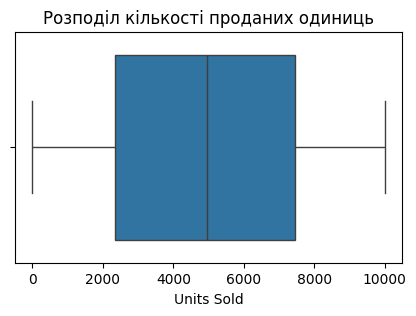

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3))
sns.boxplot(x=events["Units Sold"])
plt.title("Розподіл кількості проданих одиниць")
plt.show()

1. **Симетрія:** Медіана (лінія посередині синього прямокутника) знаходиться майже рівно по центру. Це свідчить про рівномірний розподіл продажів.
2. **Відсутність «точок» (outliers):** За межами «вусів» (горизонтальних ліній з боків) немає жодної окремої точки. Це означає, що в колонці `Units Sold` **взагалі немає статистичних викидів**.
3. **Діапазон:** Усі значення компактно вкладаються в межі від ~0 до 10 000 одиниць, що цілком відповідає описовій статистиці.


**Висновки:**

* **Аналіз описової статистики** не виявив критичних аномалій: мінімальні та максимальні значення знаходяться в межах логічних норм. Від’ємні значення та нулі у колонках кількості та ціни відсутні, що підтверджує математичну коректність даних.

* **Логічна перевірка дат** підтвердила повну часову цілісність: кількість аномалій дорівнює **0**.

* **Візуалізація викидів (Boxplot)** показала відсутність статистичних викидів (outliers). Значення рівномірно розподілені в межах типових діапазонів, що свідчить про стабільність бізнес-показників і відсутність поодиноких спотворень.

### **3. Data analysis and visualization**. Аналіз та візуалізація даних, знаходження цінних інсайтів.

#### **3.1 Об'єднання трьох таблиць в єдиний датафрейм.** Видалено непотрібні для аналізу колонки, а також виконано перейменування окремих колонок для зручності.

In [ ]:
# Об'єднання з продуктами
# Приєднуємо назву товару (item_type) за ID
df_merged = events.merge(products, left_on='Product ID', right_on='id', how='left')

# Об'єднання з країнами
# Приєднуємо назву країни та регіон за кодом alpha-3
df_final = df_merged.merge(countries, left_on='Country Code', right_on='alpha-3', how='left')

# Видалення зайвих технічних колонок та тих, що дублюються
# Видаляємо Product ID, id та alpha-3 (технічні ключі)
df_final = df_final.drop(columns=['Product ID', 'id', 'alpha-3'])

# Перейменування колонок для зручності та професійного вигляду
df_final = df_final.rename(columns={
    'item_type': 'Item Type',
    'name': 'Country',
    'region': 'Region',
    'sub-region': 'Sub-Region'
})

# Перевірка результату
print(f"Фінальна кількість колонок: {df_final.shape[1]}")
df_final.head()

Фінальна кількість колонок: 14


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Sales Channel,Units Sold,Unit Price,Unit Cost,Item Type,Country,alpha-2,Region,Sub-Region
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650,205.70,117.11,Cereal,Norway,NO,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,1993,205.70,117.11,Cereal,Serbia,RS,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,Online,4693,668.27,502.54,Household,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,Online,1171,109.28,35.84,Clothes,Montenegro,ME,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,Offline,7648,47.45,31.79,Beverages,Serbia,RS,Europe,Southern Europe


#### **3.2 Ключові метрики діяльності компанії.** Розраховано основні показники: загальна кількість замовлень, загальний прибуток, кількість охоплених країн, а також додаткові метрики для більш повної оцінки діяльності компанії.

##### **1. Розрахунок базових показників:**

In [ ]:
# Розрахунок Виручки (Ціна * Кількість)
df_final['Total Revenue'] = df_final['Unit Price'] * df_final['Units Sold']

# Розрахунок Собівартості (Собівартість одиниці * Кількість)
df_final['Total Cost'] = df_final['Unit Cost'] * df_final['Units Sold']

# Розрахунок Прибутку (Виручка − Собівартість)
df_final['Total Profit'] = df_final['Total Revenue'] - df_final['Total Cost']

# Розрахунок Маржі (%) (Прибуток / Виручка × 100)
df_final['Margin %'] = (df_final['Total Profit'] / df_final['Total Revenue']) * 100

##### **2. Ключові метрики діяльності (KPIs):**

In [ ]:
# Загальна кількість замовлень
total_orders = df_final['Order ID'].nunique()

# Загальний прибуток (Total Profit)
total_profit = df_final['Total Profit'].sum()

# Загальна виручка (Total Revenue)
total_revenue = df_final['Total Revenue'].sum()

# Кількість унікальних країн
total_countries = df_final['Country'].nunique()

# Кількість товарних категорій
total_categories = df_final['Item Type'].nunique()

# Середній чек (Average Order Value, AOV)
# Загальна виручка, поділена на кількість унікальних замовлень
avg_order_value = total_revenue / total_orders

# Середня маржинальність (середня частка прибутку у виручці)
avg_margin = df_final['Margin %'].mean()

# Середній прибуток з одного замовлення (Profit per Order)
profit_per_order = total_profit / total_orders

# Вивід результатів
print(f"{'':=^40}")
print(f"Загальна кількість замовлень:  {total_orders:,}")
print(f"Географічне охоплення:        {total_countries} країн")
print(f"Кількість категорій товарів:  {total_categories}")
print("-" * 40)
print(f"Загальна виручка:             ${total_revenue:,.2f}")
print(f"Загальний прибуток:           ${total_profit:,.2f}")
print("-" * 40)
print(f"Середній чек (AOV):           ${avg_order_value:,.2f}")
print(f"Прибуток з замовлення:        ${profit_per_order:,.2f}")
print(f"Середня маржинальність:       {avg_margin:.2f}%")
print(f"{'':=^40}")

#%whos

Загальна кількість замовлень:  1,328
Географічне охоплення:        45 країн
Кількість категорій товарів:  12
----------------------------------------
Загальна виручка:             $1,702,129,408.21
Загальний прибуток:           $501,434,459.00
----------------------------------------
Середній чек (AOV):           $1,281,723.95
Прибуток з замовлення:        $377,586.19
Середня маржинальність:       34.10%


#### **3.3 Аналіз продажів (виручка, витрати, прибуток та популярність товарів) у розрізі:**

* #### категорій товарів;
* #### географії (країн, регіонів);
* #### каналів продажу (онлайн або офлайн).

In [ ]:
def apply_grid(ax, axis='y'):
  # Відправляємо сітку на задній план
  ax.set_axisbelow(True)

  # Налаштовуємо сітку
  if axis == 'y':
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='lightgrey')
    ax.xaxis.grid(False)
  elif axis == 'x':
    ax.xaxis.grid(True, linestyle='--', alpha=0.7, color='lightgrey')
    ax.yaxis.grid(False)
  else: # обидві осі
    ax.grid(True, linestyle='--', alpha=0.7, color='lightgrey')

  # Прибираємо зайві рамки для чистоти (Spines)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

##### **1. Аналіз у розрізі категорій товарів:**

In [ ]:
# Агрегація за категоріями
category_analysis = df_final.groupby("Item Type").agg({
    'Total Revenue': 'sum',
    'Total Cost': 'sum',
    'Total Profit': 'sum',
    'Units Sold': 'sum'
})

category_analysis['ROI %'] = category_analysis['Total Profit'] / category_analysis['Total Cost'] * 100
category_analysis['Margin %'] = category_analysis['Total Profit'] / category_analysis['Total Revenue'] * 100

print(category_analysis.sort_values(by='Total Profit', ascending=False))

                 Total Revenue    Total Cost  Total Profit  Units Sold  \
Item Type                                                                
Cosmetics         2.331548e+08  1.404315e+08   92723306.17      533291   
Office Supplies   4.022140e+08  3.242368e+08   77977176.25      617641   
Household         2.942052e+08  2.212427e+08   72962466.77      440249   
Baby Food         1.436476e+08  8.970659e+07   53940997.16      562706   
Clothes           6.462655e+07  2.119524e+07   43431314.40      591385   
Cereal            9.579140e+07  5.453637e+07   41255034.15      465685   
Vegetables        8.974673e+07  5.297073e+07   36776002.72      582544   
Meat              2.237620e+08  1.934243e+08   30337736.00      530380   
Snacks            7.478861e+07  4.776119e+07   27027422.40      490160   
Personal Care     4.557902e+07  3.160361e+07   13975410.68      557678   
Beverages         2.909316e+07  1.949150e+07    9601662.78      613133   
Fruits            5.520300e+06  4.0943

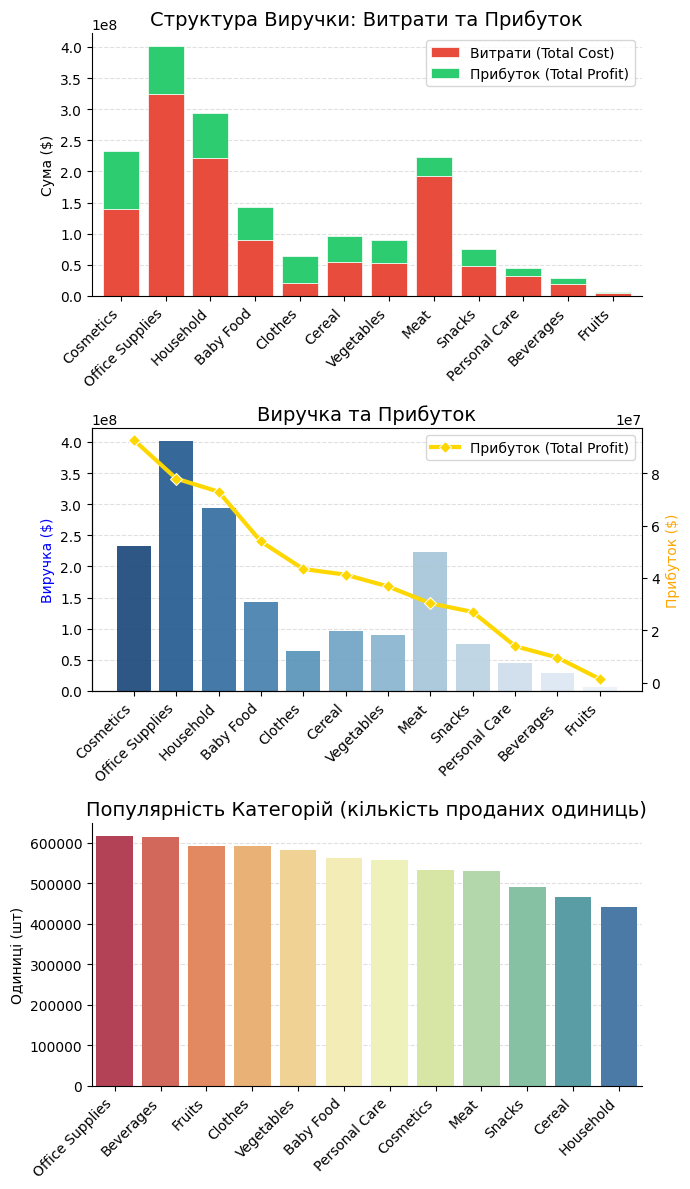

In [ ]:
# Підготовка даних (сортуємо один раз за прибутком, або перед кожним блоком)
category_analysis = category_analysis.sort_values(by='Total Profit', ascending=False)

# Створюємо фігуру на 3 графіки
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 12))

# ГРАФІК 1: Структура Виручки: Total Revenue = Total Cost + Total Profit (Pandas + Matplotlib)
category_analysis[['Total Cost', 'Total Profit']].plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#e74c3c', '#2ecc71'],
    width=0.8,
    edgecolor='white', # Біла рамка навколо кожного сегмента
    linewidth=0.5      # Товщина рамки
)

ax1.set_title('Структура Виручки: Витрати та Прибуток', fontsize=14)
ax1.set_ylabel('Сума ($)')
ax1.set_xticks(range(len(category_analysis.index)))
ax1.set_xticklabels(category_analysis.index, rotation=45, ha='right')
ax1.legend(['Витрати (Total Cost)', 'Прибуток (Total Profit)'])

# ГРАФІК 2: Виручка vs Прибуток (через Seaborn)
sns.barplot(x=category_analysis.index, y=category_analysis['Total Revenue'], ax=ax2, palette='Blues_r', hue=category_analysis.index, legend=False, alpha=0.9)

# Створюємо другу вісь
ax2_twin = ax2.twinx()
sns.lineplot(x=category_analysis.index, y=category_analysis['Total Profit'], ax=ax2_twin, color='gold', marker='D', linewidth=3, label='Прибуток (Total Profit)')

ax2.set_title('Виручка та Прибуток', fontsize=14)
ax2.set_ylabel('Виручка ($)', color='blue')
ax2_twin.set_ylabel('Прибуток ($)', color='orange')
ax2.set_xticks(range(len(category_analysis.index)))
ax2.set_xticklabels(category_analysis.index, rotation=45, ha='right')

# ГРАФІК 3: Популярність (Units Sold)
# Сортуємо за популярністю (кількістю одиниць)
category_analysis = category_analysis.sort_values(by='Units Sold', ascending=False)

sns.barplot(x=category_analysis.index, y=category_analysis['Units Sold'], ax=ax3, palette='Spectral', hue=category_analysis.index, legend=False)

ax3.set_title('Популярність Категорій (кількість проданих одиниць)', fontsize=14)
ax3.set_ylabel('Одиниці (шт)')
ax3.set_xticks(range(len(category_analysis.index)))
ax3.set_xticklabels(category_analysis.index, rotation=45, ha='right')

# Очищаємо підписи X для всіх графіків
for ax in [ax1, ax2, ax3]:
  ax.set_xlabel('')
  apply_grid(ax)

plt.tight_layout()
plt.show()

1․ Структура виручки та витрат

* **Лідер за виручкою:** категорія **Office Supplies** забезпечує найбільшу виручку (**`$402 млн`**), однак одночасно має найвищий рівень витрат (**`$324 млн`**). Це свідчить про нижчу маржинальність порівняно з найбільш прибутковими категоріями.
* **Ефективність капіталу (ROI %):** Категорія **Clothes** демонструє аномально високу рентабельність — **204.9%**. Це означає, що при відносно невеликих вкладеннях у товар, компанія отримує прибуток, що вдвічі перевищує витрати. На противагу цьому, **Meat** має найнижчий ROI (**15.7%**), що робить цей напрямок найменш вигідним для інвестування.

2․ Виручка vs Чистий прибуток (Маржинальність)

* **Головний генератор прибутку:** **Cosmetics** приносить найбільший чистий прибуток (**`$92.7 млн`**), попри те, що за виручкою посідає лише третє місце. Це досягається завдяки високій маржинальності (**39.8%**), що забезпечує значну частку прибутку від кожного продажу.
* **Запас міцності:** Найвищу частку чистого прибутку в кожному доларі виторгу має категорія **Clothes (67.2%)**. Найнижчий "запас міцності" у категорії **Meat (13.5%)** — це зона ризику, де навіть незначне зростання собівартості може призвести до збитків.

3․ Популярність та стратегія продажів (Units Sold)

* **Лідери попиту:** Найбільше одиниць товару продається в категоріях **Office Supplies** (**617 тис.**) та **Beverages** (**613 тис.**).
* **Товари-магніти:** Категорії **Fruits** та **Beverages** мають високу популярність (понад **590 тис.** одиниць), але генерують найменший прибуток. Вони виконують роль "локомотивів", які залучають клієнтів і створюють масовість продажів.
* **Елітарні продажі:** **Household** має найнижчу кількість проданих одиниць (**440 тис.**), але при цьому посідає 3-тє місце за прибутком. Це вказує на високу вартість одиниці товару та успішну стратегію "низький обсяг — високий чек".

##### **2. Аналіз у розрізі країн**:

In [ ]:
# Агрегація за країнами
country_analysis = df_final.groupby("Country").agg({
    'Total Revenue': 'sum',
    'Total Cost': 'sum',
    'Total Profit': 'sum',
    'Units Sold': 'sum'
})

country_analysis['ROI %'] = country_analysis['Total Profit'] / country_analysis['Total Cost'] * 100
country_analysis['Margin %'] = country_analysis['Total Profit'] / country_analysis['Total Revenue'] * 100

print(country_analysis.sort_values(by='Total Profit', ascending=False).head(10))

                        Total Revenue   Total Cost  Total Profit  Units Sold  \
Country                                                                        
Andorra                   47756693.17  32346656.54   15410036.63      185686   
Ukraine                   53252317.54  38447391.80   14804925.74      164577   
Malta                     47145320.81  32535192.93   14610127.88      173641   
San Marino                47883708.48  34090715.67   13792992.81      192228   
Hungary                   42408249.12  28622018.09   13786231.03      152242   
Macedonia                 49222085.25  35537985.30   13684099.95      203078   
Czech Republic            53543932.14  39908338.36   13635593.78      142446   
Russia                    46051659.81  32783977.17   13267682.64      165954   
Bosnia and Herzegovina    50117508.49  36859905.72   13257602.77      153545   
Greece                    38699541.70  26375091.57   12324450.13      176859   

                            ROI %   Mar

                        Total Revenue   Total Cost  Total Profit  Units Sold  \
Country                                                                        
Andorra                   47756693.17  32346656.54   15410036.63      185686   
Ukraine                   53252317.54  38447391.80   14804925.74      164577   
Malta                     47145320.81  32535192.93   14610127.88      173641   
San Marino                47883708.48  34090715.67   13792992.81      192228   
Hungary                   42408249.12  28622018.09   13786231.03      152242   
Macedonia                 49222085.25  35537985.30   13684099.95      203078   
Czech Republic            53543932.14  39908338.36   13635593.78      142446   
Russia                    46051659.81  32783977.17   13267682.64      165954   
Bosnia and Herzegovina    50117508.49  36859905.72   13257602.77      153545   
Greece                    38699541.70  26375091.57   12324450.13      176859   

                            ROI %   Mar

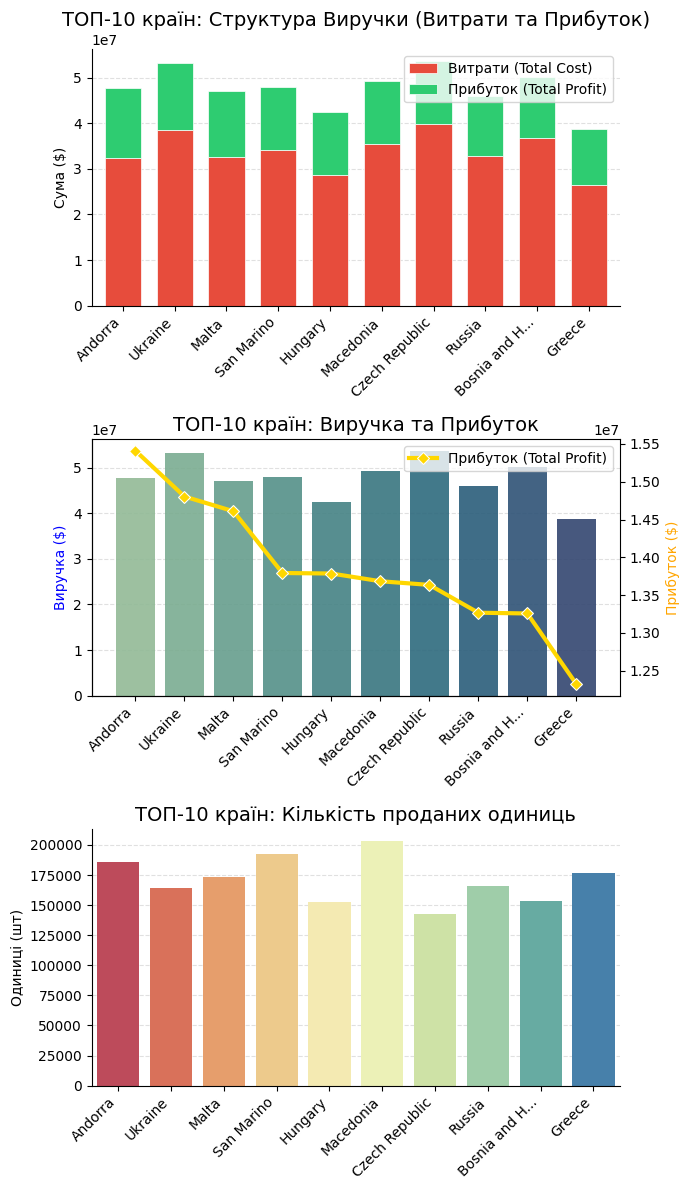

In [ ]:
# Сортуємо за прибутком і беремо ТОП-10
top10_countries = country_analysis.sort_values(by='Total Profit', ascending=False).head(10)

# Створюємо список "коротких" назв для осі X
short_names = [name[:12] + '...' if len(name) > 15 else name for name in top10_countries.index]

print(top10_countries)

# Створюємо фігуру на 3 графіки
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 12))

# ГРАФІК 1: Структура Виручки: Total Revenue = Total Cost + Total Profit (Pandas + Matplotlib)
top10_countries[['Total Cost', 'Total Profit']].plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#e74c3c', '#2ecc71'],
    width=0.7,
    edgecolor='white', # Біла рамка навколо кожного сегмента
    linewidth=0.5      # Товщина рамки
)

ax1.set_title('ТОП-10 країн: Структура Виручки (Витрати та Прибуток)', fontsize=14)
ax1.set_ylabel('Сума ($)')
ax1.legend(['Витрати (Total Cost)', 'Прибуток (Total Profit)'])

# ГРАФІК 2: Виручка та Прибуток
sns.barplot(x=short_names, y=top10_countries['Total Revenue'], ax=ax2, palette='crest', hue=short_names, legend=False, alpha=0.9)

ax2_twin = ax2.twinx()
sns.lineplot(x=short_names, y=top10_countries['Total Profit'], ax=ax2_twin, color='gold', marker='D', linewidth=3, label='Прибуток (Total Profit)')

ax2.set_title('ТОП-10 країн: Виручка та Прибуток', fontsize=14)
ax2.set_ylabel('Виручка ($)', color='blue')
ax2_twin.set_ylabel('Прибуток ($)', color='orange')

# ГРАФІК 3: Популярність (Units Sold)
sns.barplot(x=short_names, y=top10_countries['Units Sold'], ax=ax3, palette='Spectral', hue=short_names, legend=False)

ax3.set_title('ТОП-10 країн: Кількість проданих одиниць', fontsize=14)
ax3.set_ylabel('Одиниці (шт)')

for ax in [ax1, ax2, ax3]:
  ax.set_xticks(range(len(short_names))) # Явно вказуємо позиції для міток
  ax.set_xticklabels(short_names, rotation=45, ha='right')
  ax.set_xlabel('')
  apply_grid(ax)

plt.tight_layout()
plt.show()

1․ Структура виручки та витрат

* **Лідери за виручкою:** **Ukraine** та **Czech Republic** мають найвищі показники виручки (понад **$53 млн**). Це стратегічно важливі ринки з найбільшим масштабом продажів, які водночас потребують значних витрат для підтримки операційної діяльності.
* **Ефективність капіталу (ROI %):** Попри великі обсяги, **Czech Republic** має найнижчу рентабельність у ТОП-10 (**34.17%**). Натомість **Hungary** та **Andorra** є лідерами ефективності: їхній **ROI** сягає **~48%**, що означає повернення майже 50 центів чистого прибутку на кожен витрачений долар.

2․ Виручка vs Прибуток (Маржинальність)

* **Максимальний прибуток:** **Andorra** посідає 1-ше місце за прибутком (**$15.4 млн**), хоча за виручкою займає лише 6-те місце. Такий результат пояснюється високою маржинальністю ((**32.2%**): кожен долар виручки приносить більше прибутку порівняно з більшістю інших країн.

3․ Популярність та стратегія продажів (Units Sold)

* **Масовий ринок:** **Macedonia** лідирує за кількістю проданих одиниць (**203 тис. од.**). Однак її прибуток знаходиться на середньому рівні, що свідчить про реалізацію великої кількості дешевого або низькомаржинального товару.
* **Преміальна модель:** **Czech Republic** має найменшу кількість проданих одиниць (**142 тис. од.**), проте забезпечує найвищу виручку, що вказує на високу вартість кожної проданої одиниці товару.
* **Оптимальний баланс:** **San Marino** вдало поєднує високу популярність (**192 тис. од.**) із солідною рентабельністю (**ROI 40.46%**).

##### **3. Аналіз у розрізі регіонів:**

In [ ]:
# Агрегація за регіонами
region_analysis = df_final.groupby("Region").agg({
    'Total Revenue': 'sum',
    'Total Cost': 'sum',
    'Total Profit': 'sum',
    'Units Sold': 'sum'
})

region_analysis['ROI %'] = region_analysis['Total Profit'] / region_analysis['Total Cost'] * 100
region_analysis['Margin %'] = region_analysis['Total Profit'] / region_analysis['Total Revenue'] * 100

print(region_analysis.sort_values(by='Total Profit', ascending=False).head(10))

        Total Revenue    Total Cost  Total Profit  Units Sold      ROI %  \
Region                                                                     
Europe   1.505653e+09  1.057096e+09  4.485568e+08     5761244  42.432924   
Asia     9.333089e+07  6.817863e+07  2.515225e+07      410427  36.891694   

         Margin %  
Region             
Europe  29.791514  
Asia    26.949549  


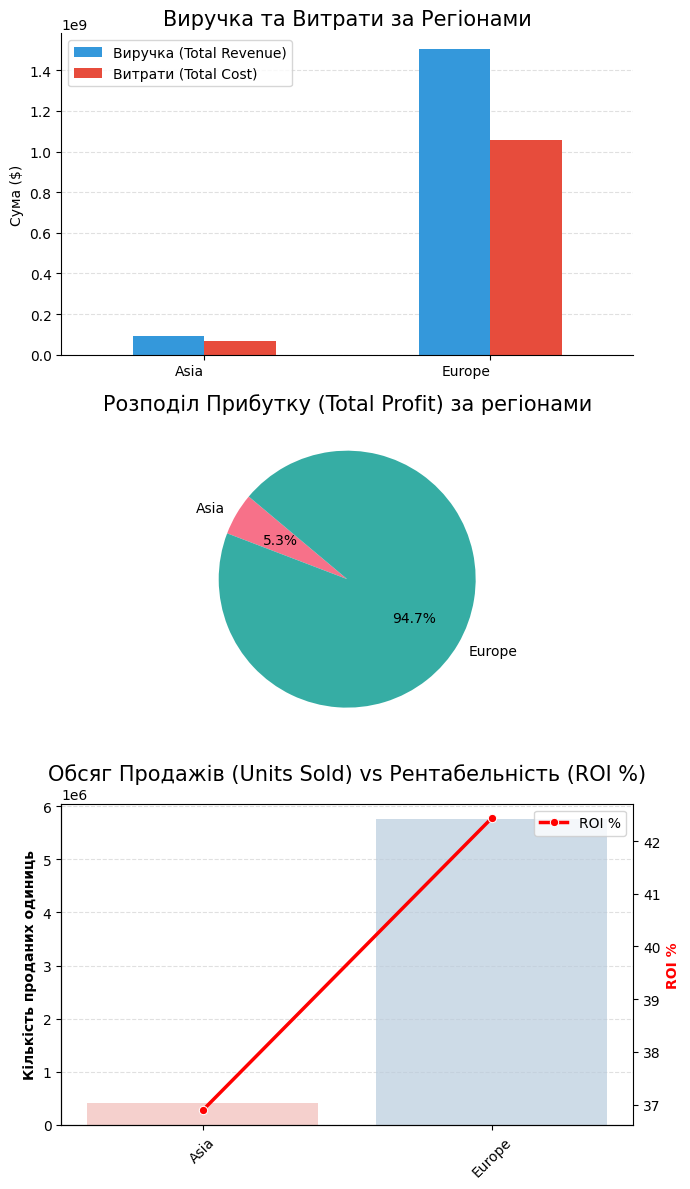

In [ ]:
# Створюємо фігуру на 3 графіки
fig, axes = plt.subplots(3, 1, figsize=(7, 12))
plt.subplots_adjust(hspace=0.4)

# ГРАФІК 1: Grouped Bar Chart: Total Revenue vs Total Cost (Pandas + Matplotlib)
region_analysis[['Total Revenue', 'Total Cost']].plot(
    kind='bar',
    ax=axes[0],
    color=['#3498db', '#e74c3c']
)

axes[0].set_title('Виручка та Витрати за Регіонами', fontsize=15)
axes[0].set_ylabel('Сума ($)')
axes[0].set_xlabel('')
axes[0].legend(["Виручка (Total Revenue)", "Витрати (Total Cost)"])
axes[0].set_xticks(range(len(region_analysis.index))) # Явно вказуємо позиції для міток
axes[0].set_xticklabels(region_analysis.index, rotation=0, ha='right')

# ГРАФІК 2: Pie Chart: Profit by Region (Pandas + Matplotlib)
# Вибираємо прибуток і малюємо кругову діаграму
region_analysis['Total Profit'].plot(kind='pie', autopct='%1.1f%%',
  startangle=140, ax=axes[1], colors=sns.color_palette('husl', len(region_analysis)))

# Прибираємо назву стовпчика збоку
axes[1].set_title('Розподіл Прибутку (Total Profit) за регіонами', fontsize=15)
axes[1].set_ylabel('')


# ГРАФІК 3: Pareto-style Bar + Line (Units Sold vs ROI %)
# Малюємо стовпчики обсягів
sns.barplot(data=region_analysis, x=region_analysis.index, y='Units Sold', ax=axes[2],
            hue=region_analysis.index, palette='Pastel1', alpha=0.7, legend=False)

axes[2].set_title('Обсяг Продажів (Units Sold) vs Рентабельність (ROI %)', fontsize=15)
axes[2].set_ylabel('Кількість проданих одиниць', fontweight='bold')
axes[2].set_xlabel('') # Прибираємо підпис осі X
axes[2].tick_params(axis='x', rotation=45)

# Створюємо праву вісь для ROI %
ax2_twin = axes[2].twinx()
sns.lineplot(data=region_analysis, x=region_analysis.index, y='ROI %', marker='o', color='red', ax=ax2_twin, linewidth=2.5, label='ROI %')

ax2_twin.set_ylabel('ROI %', color='red', fontweight='bold')

# Застосовуємо функцію сітки
for ax in axes.flatten():
  apply_grid(ax)

plt.tight_layout()
plt.show()

1. Структура виручки та витрат

* **Абсолютне домінування Європи:** **Europe** генерує виручку на рівні **`$1.5 млрд`**, що майже у 16 разів перевищує показник **Asia** (**`$93.3 млн`**). Це основний ринок, який забезпечує життєдіяльність компанії.
* **Рентабельність (ROI %):** **Європа** не лише є найбільшим ринком компанії, а й демонструє вищу ефективність. Її **ROI** становить **42.4%**, тоді як в **Азії** — **36.9%**. Це означає, що рентабельність інвестицій у європейському регіоні на **5.5 п.п.** вища, ніж в Азії.

2. Виручка, прибуток та маржинальність

* **Прибутковість:** Чистий прибуток **Європи** складає **`$448.5 млн`**, що робить її головним фінансовим донором.
* **Запас міцності (Margin %):** В **Європі** від кожного заробленого долара **29.8%** залишається в компанії. Маржинальність в **Азії** нижча (**26.9%**). Це може свідчити про вищу конкуренцію, вищі логістичні витрати або необхідність знижувати ціни для завоювання ринку.

3․ Популярність та операційна ефективність (Units Sold)

* **Обсяги:** У **Європі** продано **5.76 млн** одиниць товару проти **410 тис.** в **Азії**.
* **Середній прибуток на одиницю:** В **Європі** одна продана одиниця приносить в середньому **`$77.8`** прибутку. В **Азії** одна одиниця приносить **`$61.2`**.

##### **4. Аналіз за каналами продажу:**

In [ ]:
# Агрегація за каналами продаж
channel_analysis = df_final.groupby("Sales Channel", observed=False).agg({
    'Total Revenue': 'sum',
    'Total Cost': 'sum',
    'Total Profit': 'sum',
    'Units Sold': 'sum'
})

channel_analysis['ROI %'] = channel_analysis['Total Profit'] / channel_analysis['Total Cost'] * 100
channel_analysis['Margin %'] = channel_analysis['Total Profit'] / channel_analysis['Total Revenue'] * 100

print(channel_analysis.sort_values(by='Total Profit', ascending=False).head(10))

               Total Revenue    Total Cost  Total Profit  Units Sold  \
Sales Channel                                                          
Offline         8.717606e+08  6.182941e+08  2.534665e+08     3320363   
Online          8.303688e+08  5.824008e+08  2.479679e+08     3256161   

                   ROI %   Margin %  
Sales Channel                        
Offline        40.994491  29.075243  
Online         42.576851  29.862387  


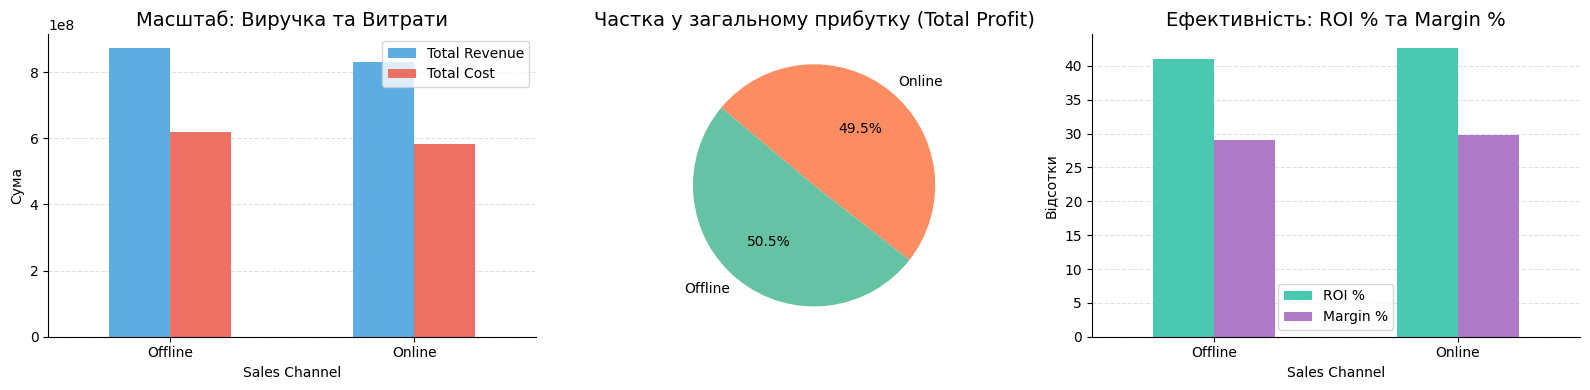

In [ ]:
# Сортуємо за виручкою
channel_analysis = channel_analysis.sort_values(by='Total Revenue', ascending=False)

# Створюємо фігуру на 3 графіки
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ГРАФІК 1: Виручка vs Витрати (Pandas + Matplotlib)
channel_analysis[['Total Revenue', 'Total Cost']].plot(kind='bar', ax=axes[0], color=['#5DADE2', '#EC7063'])

axes[0].set_title('Масштаб: Виручка та Витрати', fontsize=14)
axes[0].set_ylabel('Сума')
axes[0].set_xticklabels(channel_analysis.index, rotation=0)

# ГРАФІК 2: Частка у загальному прибутку (через Matplotlib)
axes[1].pie(channel_analysis['Total Profit'], labels=channel_analysis.index,
            autopct='%1.1f%%', startangle=140, colors=plt.cm.Set2.colors)

axes[1].set_title('Частка у загальному прибутку (Total Profit)', fontsize=14)


# ГРАФІК 3: Ефективність (ROI % та Margin %)
channel_analysis[['ROI %', 'Margin %']].plot(kind='bar', ax=axes[2], color=['#48C9B0', '#AF7AC5'])

axes[2].set_title('Ефективність: ROI % та Margin %', fontsize=14)
axes[2].set_ylabel('Відсотки')
axes[2].set_xticklabels(channel_analysis.index, rotation=0)

for ax in axes.flatten():
  apply_grid(ax)

plt.tight_layout()
plt.show()

1․ Обсяги та Виручка

* **Offline — лідер:** Цей канал генерує **`$871.7 млн`** виручки, що на **5%** більше за **Online** (**`$830.3 млн`**). Також через офлайн проходить більше фізичного товару (**3.32 млн** одиниць проти **3.25 млн**).

2․ Прибутковість та Витрати

* Різниця в чистому прибутку між каналами мінімальна (**`$253.4 млн`** в **Offline** проти **`$247.9 млн`** в **Online**).
* Однак, **Online** витрачає на **`$35.9 млн`** менше (Total Cost), щоб отримати майже такий самий прибуток, як і **Offline**.

3․ Показники ефективності (ROI & Margin)

* **Online — чемпіон з ефективності:** В онлайні **ROI %** становить **42.58%**, що на **1.58%** вище, ніж в офлайні (**40.99%**). Це означає, що кожен долар, вкладений в онлайн-інфраструктуру, повертається швидше та з більшим приростом.
* **Margin %:** Чиста маржа в онлайні також вища (**29.86%** проти **29.07%**).

#### **3.4 Аналіз інтервалу часу між замовленням та відвантаженням в розрізі:**

* категорій товарів;
* країн;
* регіонів.

In [ ]:
# Рахуємо різницю в днях
df_final['Lead Time'] = (df_final['Ship Date'] - df_final['Order Date']).dt.days

# Агрегація за категоріями
lead_by_category = df_final.groupby('Item Type')['Lead Time'].mean().sort_values(ascending=False).round(1).reset_index()

# Агрегація за країнами (ТОП-10 найдовших затримок)
lead_by_country = df_final.groupby('Country')['Lead Time'].mean().sort_values(ascending=False).round(1).head(10)

# Агрегація за регіонами
lead_by_region = df_final.groupby('Region')['Lead Time'].mean().sort_values(ascending=False).round(1)

print("Lead Time за категоріями:")
print(lead_by_category)
print("\nLead Time за країнами (ТОП-10):")
print(lead_by_country)
print("\nLead Time за регіонами:")
print(lead_by_region)

Lead Time за категоріями:
          Item Type  Lead Time
0            Cereal       27.2
1   Office Supplies       26.7
2         Baby Food       26.3
3         Cosmetics       25.9
4              Meat       25.9
5            Snacks       25.5
6            Fruits       24.4
7         Beverages       24.1
8         Household       23.9
9        Vegetables       23.5
10          Clothes       23.1
11    Personal Care       20.8

Lead Time за країнами (ТОП-10):
Country
Hungary       32.6
Georgia       29.7
Austria       28.5
Slovakia      28.5
Luxembourg    27.8
Lithuania     27.6
Poland        27.5
Russia        27.4
Monaco        26.8
Bulgaria      26.8
Name: Lead Time, dtype: float64

Lead Time за регіонами:
Region
Asia      26.1
Europe    24.8
Name: Lead Time, dtype: float64


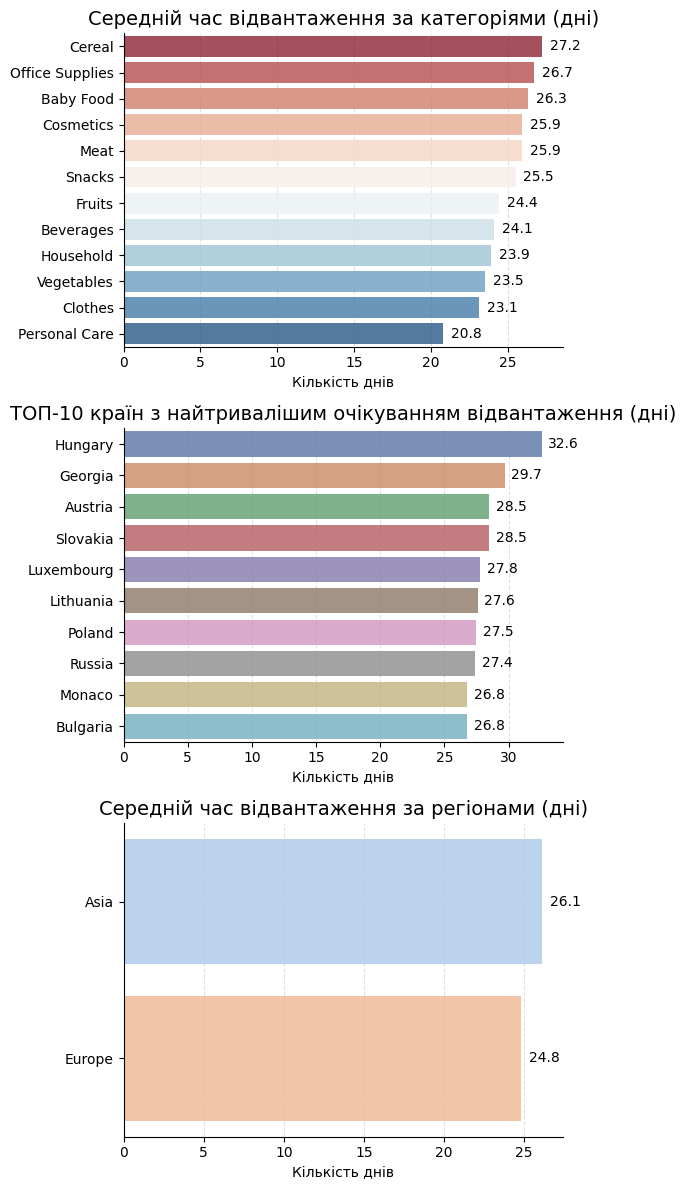

In [ ]:
# Створюємо фігуру на 3 графіки
fig, axes = plt.subplots(3, 1, figsize=(6, 12))

# ГРАФІК 1: За категоріями
sns.barplot(
    data=lead_by_category,
    x='Lead Time',
    y='Item Type',
    ax=axes[0],
    palette='RdBu',
    alpha=0.8,
    hue='Item Type',             # Додаємо hue (те саме, що і вісь Y)
    legend=False                 # Вимикаємо легенду
)
axes[0].set_title('Середній час відвантаження за категоріями (дні)', fontsize=14)


# ГРАФІК 2: За країнами (ТОП-10 найдовших затримок)
sns.barplot(
    x=lead_by_country.values,
    y=lead_by_country.index,
    ax=axes[1],
    palette='deep',  # crest, flare_r, rocket, mako, vlag, muted
    alpha=0.8,
    hue=lead_by_country.index,  # Додаємо hue (те саме, що і вісь Y)
    legend=False                 # Вимикаємо легенду
)
axes[1].set_title('ТОП-10 країн з найтривалішим очікуванням відвантаження (дні)', fontsize=14)

# ГРАФІК 3: За регіонами
sns.barplot(
    x=lead_by_region.values,
    y=lead_by_region.index,
    ax=axes[2],
    palette='pastel', # icefire
    alpha=0.8,
    hue=lead_by_region.index,  # Додаємо hue (те саме, що і вісь Y)
    legend=False                 # Вимикаємо легенду
)
axes[2].set_title('Середній час відвантаження за регіонами (дні)', fontsize=14)

for ax in axes.flatten():
  ax.set_xlabel('Кількість днів') # Додаємо підпис осі X
  ax.set_ylabel('')
  apply_grid(ax, axis='x')

  # Додаємо підписи значень на стовпчики
  for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}',
     (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
      va='center', fontsize=10, color='black', fontweight='normal')

plt.tight_layout()
plt.show()

* **Категорії:** Найдовше відвантажуються **Cereal (27.2 дні)** та **Office Supplies (26.7 днів)**. Це може бути пов’язано з особливостями пакування або великим об'ємом цих товарів. Найшвидша категорія — **Personal Care (20.8 днів)**, що майже на тиждень швидше за лідера.
* **Країни:** У **Hungary** спостерігається аномально високий показник — **32.6 дні**. Це "червона зона". Вся перша десятка перевищує 26 днів, що вказує на логістичні труднощі в європейському напрямку (оскільки більшість країн у ТОП-10 — європейські).
* **Регіони:** **Азія (26.1)** працює повільніше за **Європу (24.8)**. Хоча різниця в 1.3 дня здається невеликою, у масштабах тисяч замовлень це суттєве навантаження на складські ресурси.

#### **3.5 Аналіз залежності прибутку від часу відвантаження товару.** Проведено агрегування та побудовано візуалізації для перевірки цієї залежності.

In [ ]:
# Агрегуємо дані: середній прибуток залежно від кількості днів очікування
profit_by_lead_time = df_final.groupby('Lead Time')['Total Profit'].mean().reset_index()

print(profit_by_lead_time.head())

# Розрахуємо коефіцієнт кореляції Пірсона
correlation = df_final['Lead Time'].corr(df_final['Total Profit'])

print(f"\nКоефіцієнт кореляції між часом відвантаження та прибутком: {correlation:.4f}")

   Lead Time   Total Profit
0          0  348379.706000
1          1  309541.679091
2          2  339626.031154
3          3  285222.778788
4          4  300644.403548

Коефіцієнт кореляції між часом відвантаження та прибутком: 0.0603


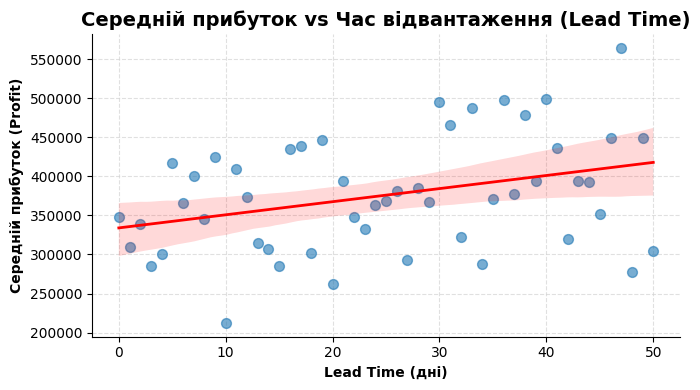

In [ ]:
# Створюємо фігуру
plt.figure(figsize=(7, 4))

# Використовуємо regplot для автоматичної побудови лінії регресії
sns.regplot(data=profit_by_lead_time, x='Lead Time', y='Total Profit',
  scatter_kws={'alpha':0.6, 's':50}, line_kws={'color':'red', 'lw':2}, ci=95)

plt.title('Cередній прибуток vs Час відвантаження (Lead Time)', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time (дні)', fontweight='semibold')
plt.ylabel('Середній прибуток (Profit)', fontweight='semibold')
apply_grid(plt.gca(), axis='both')

plt.tight_layout()
plt.show()

**1. Інтерпретація коефіцієнта кореляції**

Коефіцієнт кореляції Пірсона становить **0.0603**.

* В аналітиці це класифікується як **дуже слабкий позитивний лінійний зв'язок** між часом відвантаження та прибутком.
* Це означає, що **час, витрачений на відвантаження, фактично не впливає на розмір прибутку**.

**2. Аналіз візуалізації (RegPlot)**

* **Лінія регресії** має незначний висхідний нахил, що відповідає слабкій позитивній кореляції, однак вираженого тренду не спостерігається.
* **Довірчий інтервал (рожева зона):** Помітно, що він розширюється в правій частині графіка. Це свідчить про меншу кількість спостережень і вищу невизначеність оцінок для тривалих термінів відвантаження (40–50 днів).

**3. Бізнес-висновки**

* **"Швидкість не дорівнює грошам":** Прямого зв'язку між швидкістю відвантаження та прибутком не виявлено.  Клієнти, чиї замовлення готуються довго, приносять стільки ж грошей, скільки й ті, хто отримує товар швидко.

* **Окремі аномалії:** Пік середнього прибутку на **47-й день** (понад **550 тис.**) та його зниження на **10-й день** (нижче **250 тис.**) можуть бути пов'язані з невеликою кількістю спостережень для відповідних значень `Lead Time` або впливом окремих великих замовлень.

#### **3.6 Динаміка продажів у часі в розрізі категорій, країн і регіонів.**
За допомогою візуалізацій досліджено основні тенденції продажів у розрізі категорій товарів, країн та регіонів.

##### **1. Динаміка продажів у розрізі категорій:**

Item Type  Office Supplies    Household   Cosmetics         Meat    Baby Food
Year                                                                         
2010           40776816.57  33551831.89  25620357.2  36099439.74  18351313.36
2011           58527498.75  30088188.48  39341879.2  30471005.25  14521092.24
2012           52324072.29  43688151.25  56664180.4  40162662.33  28261538.24
2013           40862125.08  29934486.38  14507607.6  25896873.87  18354887.28
2014           56529586.47  46085904.01  30832655.6  23268499.17  26004097.20
2015           75447888.18  46133351.18  20544902.4  28157782.38  19961109.04
2016           43534690.92  42542068.20  18402622.4  21259880.88  12321599.76
2017           34211317.35  22181217.84  27240620.4  18445874.58   5871950.56


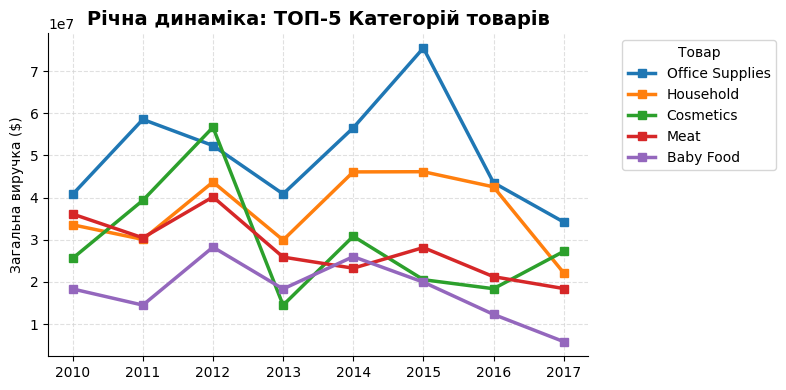

In [ ]:
# Створюємо колонку року
df_final['Year'] = df_final['Order Date'].dt.year

# ГРАФІК 1: Річна динаміка ТОП-5 Категорій
plt.figure(figsize=(8, 4))

top_5_categories = df_final.groupby('Item Type')['Total Revenue'].sum().nlargest(5).index
category_annual = df_final[df_final['Item Type'].isin(top_5_categories)] \
  .groupby(['Year', 'Item Type'])['Total Revenue'].sum().unstack(fill_value=0)

# Пересортовуємо колонки згідно з ТОП-5 Категорій
category_annual = category_annual[top_5_categories]

print(category_annual)

# Малюємо графік (через Pandas)
category_annual.plot(kind='line', marker='s', linewidth=2.5, ax=plt.gca())

plt.title('Річна динаміка: ТОП-5 Категорій товарів', fontsize=14, fontweight='bold')
plt.ylabel('Загальна виручка ($)')
plt.xlabel('')
plt.legend(title='Товар', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(category_annual.index)
apply_grid(plt.gca(), axis='both')

plt.tight_layout()
plt.show()

1. **Лідери та піки:** Категорія **Office Supplies** є абсолютним лідером за обсягом виторгу, досягнувши свого максимуму (понад **`$75 млн`**) у **2015** році.
2. **Волатильність:** Продажі в категорії **Cosmetics** демонструють найбільшу нестабільність, маючи різкі стрибки (наприклад, обвал у **2013** році з наступним відновленням).
3. **Рецесія ринку:** Починаючи з **2016** року, більшість категорій (зокрема лідер **Office Supplies**) демонструють стрімке падіння виторгу, що свідчить про загальне зниження попиту на ринку наприкінці досліджуваного періоду.
Категорія **Cosmetics** є єдиною, що не показала падіння після **2016** року — це свідчить про низьку еластичність попиту на косметичні товари.

##### **2. Динаміка продажів у розрізі країн:**

Country  Czech Republic      Ukraine  Bosnia and Herzegovina    Macedonia  \
Year                                                                        
2010         8110413.30   3194980.65              1331049.52   2287760.92   
2011        15639309.03   8946152.38              2520932.36         0.00   
2012         2217746.82  13994664.31             20506108.34   2681494.87   
2013         1419947.10    345008.95              4399195.84   2848802.16   
2014        14761657.41   8028817.86               397495.31   6793562.66   
2015         6911639.34   5631454.86             17905347.83  16448519.15   
2016         1775727.68   5764026.00              3057379.29   5257799.87   
2017         2707491.46   7347212.53                    0.00  12904145.62   

Country  San Marino      Andorra     Portugal        Malta       Russia  \
Year                                                                      
2010     2387947.07  10463527.98   3372587.50   4793614.62  11983040.08   
2011

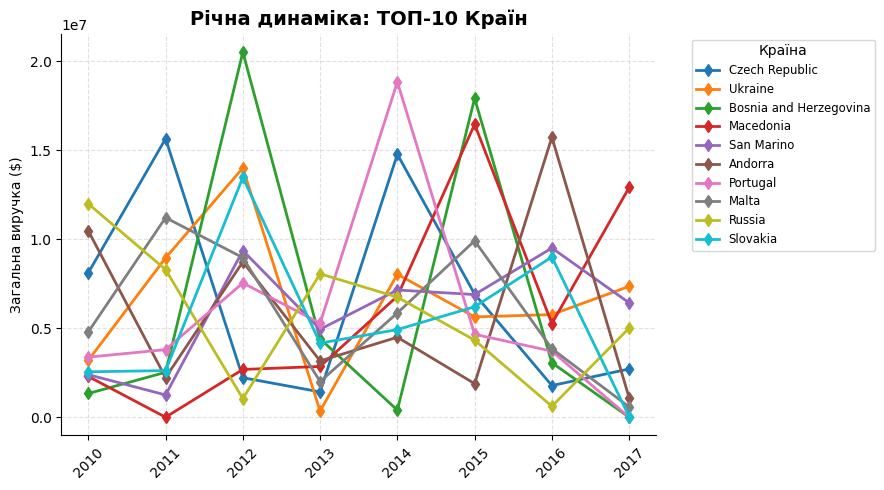

In [ ]:
# ГРАФІК 2: Річна динаміка ТОП-10 Країн
plt.figure(figsize=(9, 5))

top_10_countries = df_final.groupby('Country')['Total Revenue'].sum().nlargest(10).index
country_annual = df_final[df_final['Country'].isin(top_10_countries)] \
  .groupby(['Year', 'Country'])['Total Revenue'].sum().unstack(fill_value=0)

# Пересортовуємо колонки згідно з ТОП-10 Країн
country_annual = country_annual[top_10_countries]

print(country_annual)

# Малюємо графік (через Pandas)
country_annual.plot(kind='line', marker='d', linewidth=2, ax=plt.gca(), colormap='tab10')

plt.title('Річна динаміка: ТОП-10 Країн', fontsize=14, fontweight='bold')
plt.ylabel('Загальна виручка ($)')
plt.xlabel('')
plt.legend(title='Країна', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.xticks(country_annual.index, rotation=45)
apply_grid(plt.gca(), axis='both')

plt.tight_layout()
plt.show()

1. **Відсутність стабільності:** У жодній країні немає постійного росту; виторг приходить "хвилями", що характерно для великих разових контрактів, а не роздрібної торгівлі.
2. **Локальні рекорди:** **Боснія і Герцеговина** показала найвищий разовий результат у **2012** році (**`$20.5 млн`**), а **Португалія** — у **2014** році (**`$18.8 млн`**).
3. **Фінальний стан:** На **2017** рік лише **Македонія** та **Україна** зберігають відносно високі обсяги виторгу, тоді як інші країни ТОП-10 знаходяться у глибокому спаді.

##### **3. Динаміка продажів у розрізі pегіонів:**

    Year  Region  Total Revenue
0   2010    Asia   1.404036e+07
1   2010  Europe   1.882141e+08
2   2011    Asia   4.347440e+06
3   2011  Europe   2.098649e+08
4   2012    Asia   2.179092e+07
5   2012  Europe   2.457695e+08
6   2013    Asia   1.233149e+07
7   2013  Europe   1.630246e+08
8   2014    Asia   1.227657e+07
9   2014  Europe   2.046980e+08
10  2015    Asia   1.476692e+07
11  2015  Europe   1.992201e+08
12  2016    Asia   6.243820e+06
13  2016  Europe   1.750343e+08
14  2017    Asia   7.533370e+06
15  2017  Europe   1.198274e+08


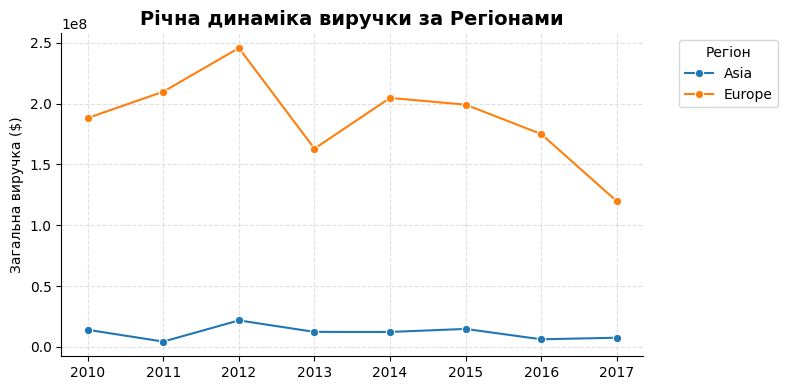

In [ ]:
# ГРАФІК 3: Річна динаміка за Регіонами
plt.figure(figsize=(8, 4))

region_annual = df_final.groupby(['Year', 'Region'])['Total Revenue'].sum().reset_index()
print(region_annual)

# Малюємо графік (через Seaborn)
sns.lineplot(data=region_annual, x="Year", y="Total Revenue", hue="Region", marker="o")

plt.title('Річна динаміка виручки за Регіонами', fontsize=14, fontweight='bold')
plt.ylabel('Загальна виручка ($)')
plt.xlabel('')
plt.legend(title='Регіон', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(region_annual['Year'].unique())
apply_grid(plt.gca(), axis='both')

plt.tight_layout()
plt.show()

1. **Домінування Європи:** Європа є основним джерелом виручки компанії, випереджаючи Азію в середньому у **10–15 разів** за обсягом продажів. Максимальний рівень виручки було зафіксовано у 2012 році — майже **`$246 млн`**.
2. **Негативний тренд у Європі:** Починаючи з 2015 року, спостерігається стрімке зниження виручки. До 2017 року її обсяг скоротився до **`$119.8 млн`**, що є найнижчим показником за весь досліджуваний період.
3. **Стагнація в Азії:** Азійський ринок залишається на низькому рівні з постійними коливаннями (від **`$4.3 млн`** до **`$21.7 млн`**), не демонструючи ознак стабільного зростання.

#### **3.7 Аналіз продажів товарів за днями тижня та сезонність.**
Досліджено розподіл продажів за днями тижня та визначено, чи можна окремі товари вважати сезонними.

Weekday
Monday       2.754685e+08
Tuesday      2.135239e+08
Wednesday    2.612157e+08
Thursday     2.149222e+08
Friday       2.638070e+08
Saturday     2.336411e+08
Sunday       2.395510e+08
Name: Total Revenue, dtype: float64


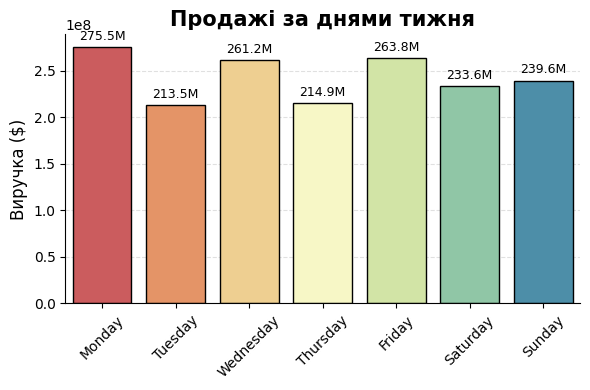

In [ ]:
import numpy as np

# Додаємо назву дня тижня
df_final['Weekday'] = df_final['Order Date'].dt.day_name()

# Групуємо
weekday_sales = df_final.groupby('Weekday')['Total Revenue'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print(weekday_sales)

# Задаємо розмір перед побудовою
plt.figure(figsize=(6, 4))

# Будуємо графік (через Seaborn)
ax = sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    palette='Spectral',
    hue=weekday_sales.index,
    edgecolor='black',
    alpha=1.0,
    legend=False # Щоб приховати зайву легенду від hue
)

# Додаємо підписи значень на стовпчиках
for container in ax.containers:
    labels = [f'{v/1_000_000:.1f}M' for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=3)

plt.title('Продажі за днями тижня', fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Виручка ($)', fontsize=12)
plt.xticks(rotation=45)
apply_grid(plt.gca(), axis='y')

plt.tight_layout()
plt.show()

1. **Лідери тижня**: **Понеділок** — абсолютний пік (**`$275 млн`**). Це часто вказує на те, що клієнти накопичують потреби за вихідні або бізнес-замовлення обробляються на початку робочого тижня. **Середа та П'ятниця** — "друга хвиля" активності. Продажі знову зростають до рівня **`$261–$263 млн`**.

2. **Рівномірність продажів**: Продажі не мають критичних провалів. Навіть у найслабші дні (**Вівторок**, **Четвер**) виручка перевищує **`$213 млн`**, що свідчить про стабільний попит протягом усього тижня.

3. **Вихідні дні**: **Субота** та **Неділя** демонструють середні показники (**`$233–$239 млн`**). Це вище за деякі будні дні (вівторок/четвер). Це означає, що товар має попит і серед приватних покупців, які роблять покупки у вільний час.

Season                Winter        Spring       Summer       Autumn
Item Type                                                           
Baby Food        37472551.20  4.055199e+07  35286588.56  30336454.08
Beverages         8025882.80  6.298418e+06   7557219.15   7211640.80
Cereal           26607295.00  1.355090e+07  28508580.10  27124630.50
Clothes          12026810.40  2.368939e+07  16333753.76  12576598.08
Cosmetics        67606859.20  5.154457e+07  55911759.20  58091638.40
Fruits             906661.41  1.718875e+06   1202189.16   1692573.96
Household        71216197.36  7.224600e+07  89557535.78  61185464.66
Meat             64868962.62  4.740061e+07  67322252.97  44170195.44
Office Supplies  99021038.97  1.273135e+08  87032262.87  88847185.14
Personal Care    13997651.91  1.230903e+07  10169745.63   9102597.02
Snacks           20920091.22  1.900414e+07  19494536.28  15369841.14
Vegetables       23874216.02  2.610809e+07  20860340.24  18904086.36


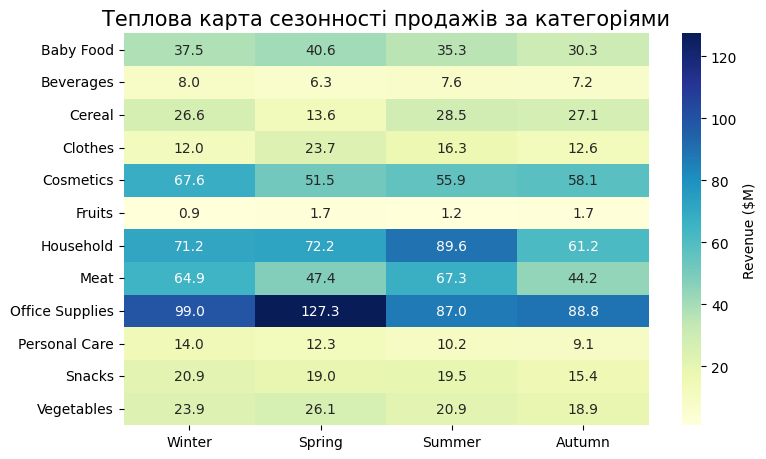

In [65]:
# Створюємо словник для маппінгу місяців у сезони
season_map = {
    1: 'Winter', 2: 'Winter', 3: 'Spring',
    4: 'Spring', 5: 'Spring', 6: 'Summer',
    7: 'Summer', 8: 'Summer', 9: 'Autumn',
    10: 'Autumn', 11: 'Autumn', 12: 'Winter'
}

# Додаємо колонку Month, а потім на її основі — Season
df_final['Month'] = df_final['Order Date'].dt.month
df_final['Season'] = df_final['Month'].map(season_map)

# Створюємо зведену таблицю: Сезони по горизонталі, Категорії по вертикалі
pivot_seasonal = df_final.pivot_table(index='Item Type', columns='Season', values='Total Revenue', aggfunc='sum')

# Сортуємо сезони у хронологічному порядку
pivot_seasonal = pivot_seasonal.reindex(columns=['Winter', 'Spring', 'Summer', 'Autumn'])

# Перетворюємо значення у відсотки (по кожному рядку)
# .div(axis=0) ділить кожне значення на суму рядка
pivot_percent = pivot_seasonal.div(pivot_seasonal.sum(axis=1), axis=0) * 100

print(pivot_seasonal)

pivot_seasonal_m = pivot_seasonal / 1_000_000

plt.figure(figsize=(8, 4.7))
# Малюємо теплову карту
sns.heatmap(pivot_seasonal_m, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Revenue ($M)'})

plt.title('Теплова карта сезонності продажів за категоріями', fontsize=15)
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

**1. Товари з вираженою сезонністю**

* **Office Supplies (Канцтовари):** Абсолютний пік весною (**`$127.3 млн`**). Це може бути пов’язано з початком звітних періодів або підготовкою до навчальних сезонів у певних регіонах.
* **Household (Побутові товари):** Демонструють максимальний попит влітку (**`$89.6 млн`**). Це період активного оновлення осель та ремонтів.
* **Meat:** Продажі влітку (**`$67 млн`**) та взимку (**`$65 млн`**) значно перевищують показники весни та осені. Це вказує на сезон пікніків (літо) та святковий сезон (зима).

**2. Категорії зі стабільним попитом**

* **Beverages:** Стабільно низькі коливання (від **`$6.3 млн`** до **`$8 млн`**). Це товар повсякденного вжитку.
* **Baby Food:** Попит залишається рівномірним протягом року, оскільки це продукт першої необхідності.

**3. Специфічні сезонні закономірності**

* **Clothes:** Весна — найсильніший сезон (**`$23.7 млн`**), що майже вдвічі більше за зимові показники (**`$12 млн`**). Це свідчить про активне оновлення гардероба перед літнім сезоном.
* **Fruits:** Хоча це найменша за виручкою категорія, вона демонструє виражену сезонність. У зимовий період виручка знижується до **`$900 тис.`**, що майже вдвічі менше порівняно з весняним та осіннім періодами.

### **Ключові висновки та рекомендації**

#### 1. Ефективність портфеля товарів

* Хоча **Office Supplies** генерує найбільший оборот (**`$402 млн`**), він має низьку маржинальність (**19.4%**) і довгий цикл відвантаження (**26.7 днів**). Необхідно переглянути логістику цієї категорії.
* Категорії **Cosmetics** та **Clothes** є ключовими драйверами прибутковості компанії. **Cosmetics** — лідер за чистим прибутком (**`$92.7 млн`**). **Clothes** — має аномально високий **ROI** (**204.9%**). Рекомендується перенаправити маркетинговий бюджет з низькорентабельного сегмента **Meat** (**ROI 15.7%**) у **Clothes**, де кожен вкладений долар приносить у 13 разів більше чистого прибутку.
* **Beverages** та **Fruits** приносять мінімальний чистий прибуток (**`$9.6 млн`** та **` $1.4 млн`**), але забезпечують масовість (понад **590 тис.** одиниць кожна). Їх не можна скорочувати, оскільки вони формують клієнтську базу для допродажу висомаржинальних товарів.

#### 2. Географічна експансія

* Домінування **Європи** (**94%** виручки) є критичним ризиком. Враховуючи стрімке падіння виторгу в **Європі** з **2015** року, компанії потрібна стратегія стабілізації в **Україні** та **Чехії**, а також активніша експансія в **Азію**, яка наразі стагнує.
* **Андорра** — ідеальна модель ринку. Маючи середній оборот (**`$47.7 млн`**), вона дає найвищий чистий прибуток (**`$15.4 млн`**) завдяки високій маржі (**32.2%**). Варто вивчити досвід роботи в **Андоррі** для масштабування на інші невеликі європейські країни.

#### 3. Оптимізація каналів та логістики

* **Онлайн**-канал демонструє вищу рентабельність (**ROI 42.58%**) за нижчих витрат. Стратегічно вигідно стимулювати перехід клієнтів з **Offline** в **Online** через систему бонусів.
* Відсутність кореляції між часом відвантаження та прибутком свідчить про те, що клієнти готові чекати. Однак затримка у **32 дні** (**Угорщина**) є аномальною і може призвести до відтоку клієнтів. Необхідно поліпшити логістичні процеси та оптимізувати ланцюги постачання, щоб наблизити середній час відвантаження до рівня категорії **Personal Care** (**21 день**).